In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from data_science.plots import plot_cumulative_explained_variance
from data_science.styles import apply_luna_style

In [4]:
apply_luna_style()

## Data

In [5]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [6]:
data = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names,
)

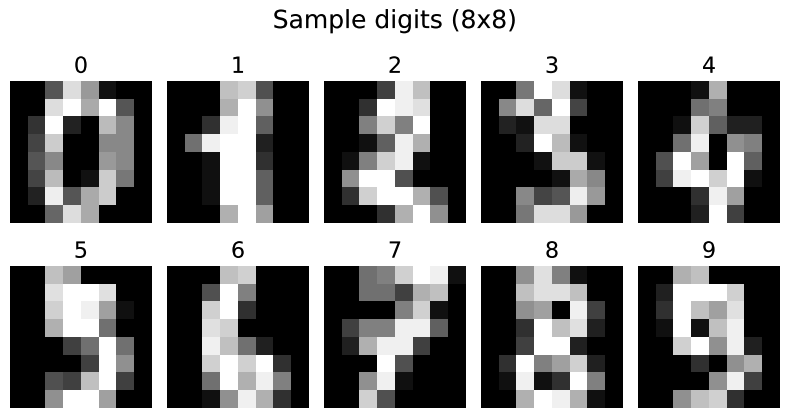

In [7]:
images = dataset.images
fig, axes = plt.subplots(2, 5, figsize=(8, 4.5))
plt.gray()
for ax, img, label in zip(axes.ravel(), images[:10], dataset.target[:10], strict=True):
    ax.imshow(img)
    ax.set_title(f"{label}", fontsize=16)
    ax.axis("off")
plt.suptitle("Sample digits (8x8)", fontsize=18)
plt.tight_layout()
plt.show()

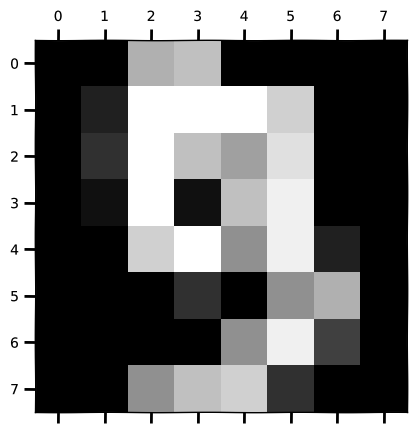

In [8]:
plt.matshow(dataset.data[9].reshape(8, 8))

## Basic Statistics


In [9]:
data.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 64 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

## Prepare Data


In [11]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x12C463060

In [12]:
X = data
y = dataset.target

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

## LogisticRegression

### Without PCA

In [15]:
lr_no_pca = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
lr_no_pca.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred_no_pca = lr_no_pca.predict(X_test)

In [17]:
print("Logistic Regression without PCA Results:")
accuracy = accuracy_score(y_test, y_pred_no_pca)
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred_no_pca, average="weighted")
print(f"Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_no_pca))

Logistic Regression without PCA Results:
Accuracy: 97.22%
Precision: 97.25%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [18]:
cm = confusion_matrix(y_test, y_pred_no_pca)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  0  0  1  0  0  0  0  1 38]]


### With PCA (variance threshold = 0.95)

In [19]:
pca_95 = PCA(
    n_components=0.95,
    svd_solver="full",
    random_state=RANDOM_STATE,
)

In [20]:
X_pca_95 = pca_95.fit_transform(X_scaled)
X_pca_95.shape

(1797, 40)

In [21]:
pca_95.explained_variance_ratio_

array([0.12033916, 0.09561054, 0.08444415, 0.06498408, 0.04860155,
       0.0421412 , 0.03942083, 0.03389381, 0.02998221, 0.02932003,
       0.02781805, 0.02577055, 0.02275303, 0.0222718 , 0.02165229,
       0.01914167, 0.01775547, 0.01638069, 0.0159646 , 0.01489191,
       0.0134797 , 0.01271931, 0.01165837, 0.01057647, 0.00975316,
       0.00944559, 0.00863014, 0.00836643, 0.00797693, 0.00746471,
       0.00725582, 0.00691911, 0.00653909, 0.00640793, 0.00591384,
       0.00571162, 0.00523637, 0.00481808, 0.00453719, 0.00423163])

In [22]:
pca_95.explained_variance_ratio_.sum()

np.float64(0.9507791125066462)

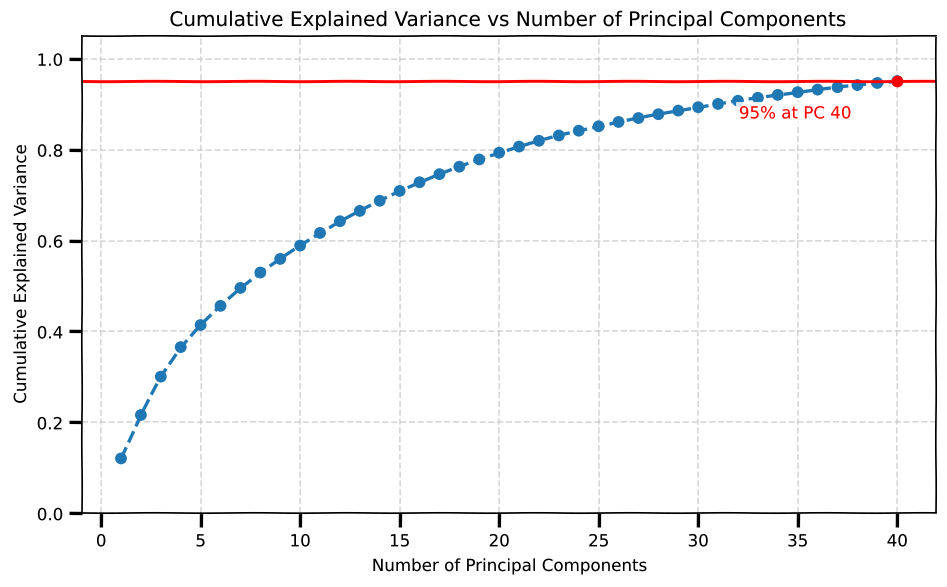

In [23]:
plot_cumulative_explained_variance(pca_95, threshold=0.95)

In [24]:
X_train_pca_95, X_test_pca_95, y_train, y_test = train_test_split(
    X_pca_95,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

In [25]:
model_pca_95 = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model_pca_95.fit(X_train_pca_95, y_train)
model_pca_95.score(X_test_pca_95, y_test)

0.9611111111111111

In [26]:
y_pred_pca_95 = model_pca_95.predict(X_test_pca_95)

In [27]:
print("Logistic Regression without PCA Results:")
accuracy = accuracy_score(y_test, y_pred_pca_95)
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred_pca_95, average="weighted")
print(f"Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca_95))

Logistic Regression without PCA Results:
Accuracy: 96.11%
Precision: 96.14%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      0.96      0.95        28
           2       0.97      0.97      0.97        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.92      0.94      0.93        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.90      0.90      0.90        30
           9       0.95      0.93      0.94        40

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



In [28]:
cm = confusion_matrix(y_test, y_pred_pca_95)
print("Confusion Matrix for PCA with 95% Variance:")
print(cm)

Confusion Matrix for PCA with 95% Variance:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 27  1  0  0  0  0  0  0  0]
 [ 0  0 32  0  0  0  0  0  1  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  2  0  0  0  1  0  0 27  0]
 [ 0  0  0  1  0  0  0  0  2 37]]


### With PCA (20 components)

In [29]:
pca_20d = PCA(
    n_components=20,
    svd_solver="full",
    random_state=RANDOM_STATE,
)

In [30]:
X_pca_20d = pca_20d.fit_transform(X_scaled)
X_pca_20d.shape

(1797, 20)

In [31]:
pca_20d.explained_variance_ratio_

array([0.12033916, 0.09561054, 0.08444415, 0.06498408, 0.04860155,
       0.0421412 , 0.03942083, 0.03389381, 0.02998221, 0.02932003,
       0.02781805, 0.02577055, 0.02275303, 0.0222718 , 0.02165229,
       0.01914167, 0.01775547, 0.01638069, 0.0159646 , 0.01489191])

In [32]:
pca_20d.explained_variance_ratio_.sum()

np.float64(0.7931376270240806)

In [33]:
X_train_pca_20d, X_test_pca_20d, y_train, y_test = train_test_split(
    X_pca_20d,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

In [34]:
model_pca_20d = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model_pca_20d.fit(X_train_pca_20d, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred_pca_20d = model_pca_20d.predict(X_test_pca_20d)

In [36]:
print("Logistic Regression without PCA Results:")
accuracy = accuracy_score(y_test, y_pred_pca_20d)
print(f"Accuracy: {accuracy * 100:.2f}%")
precision = precision_score(y_test, y_pred_pca_20d, average="weighted")
print(f"Precision: {precision * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca_20d))

Logistic Regression without PCA Results:
Accuracy: 94.17%
Precision: 94.33%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.89      0.89      0.89        28
           2       0.86      0.91      0.88        33
           3       1.00      0.91      0.95        34
           4       0.98      1.00      0.99        46
           5       0.93      0.91      0.92        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.88      0.97      0.92        30
           9       0.90      0.90      0.90        40

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



In [37]:
cm = confusion_matrix(y_test, y_pred_pca_20d)
print("Confusion Matrix for PCA with 20 Components:")
print(cm)

Confusion Matrix for PCA with 20 Components:
[[32  0  1  0  0  0  0  0  0  0]
 [ 0 25  2  0  0  0  0  0  0  1]
 [ 0  2 30  0  0  0  0  0  1  0]
 [ 0  0  1 31  0  1  0  0  1  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  1  0  0 43  1  0  0  2]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  1  0  0  0  1  0  0  2 36]]
